# Week 5 exercises: Visualization and A/B Testing — Solutions

---

In [1]:
# Importing needed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1: Visualization with Seaborn

### Exercise 1: Scatter plots and distributions

We will use the built-in Seaborn dataset `tips`, which contains data on restaurant bills, tips, and customer attributes.

a) Load the `tips` dataset using `sns.load_dataset()`. Doing some exploratory data analysis is probably a good idea, or reading about the dataset online at least.

b) Create a scatter plot of `total_bill` vs. `tip`, colored by `time` (Lunch vs. Dinner). Add a meaningful title and axis labels.

c) Create a histogram of `total_bill`. Experiment with different values of `bins` (e.g. 10, 20, 50). How does the bin count affect the appearance?

d) Create a KDE plot of `total_bill` grouped by `time` using `sns.kdeplot()` with `fill=True`. Do lunch and dinner bills have different distributions?

In [2]:
# a) Solution
tips = sns.load_dataset("tips")
display(tips.head())

tips.describe()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


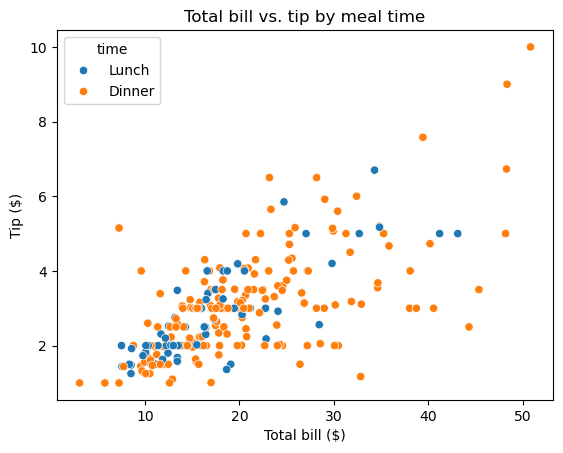

In [3]:
# b) Solution
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.title("Total bill vs. tip by meal time")
plt.xlabel("Total bill ($)")
plt.ylabel("Tip ($)");

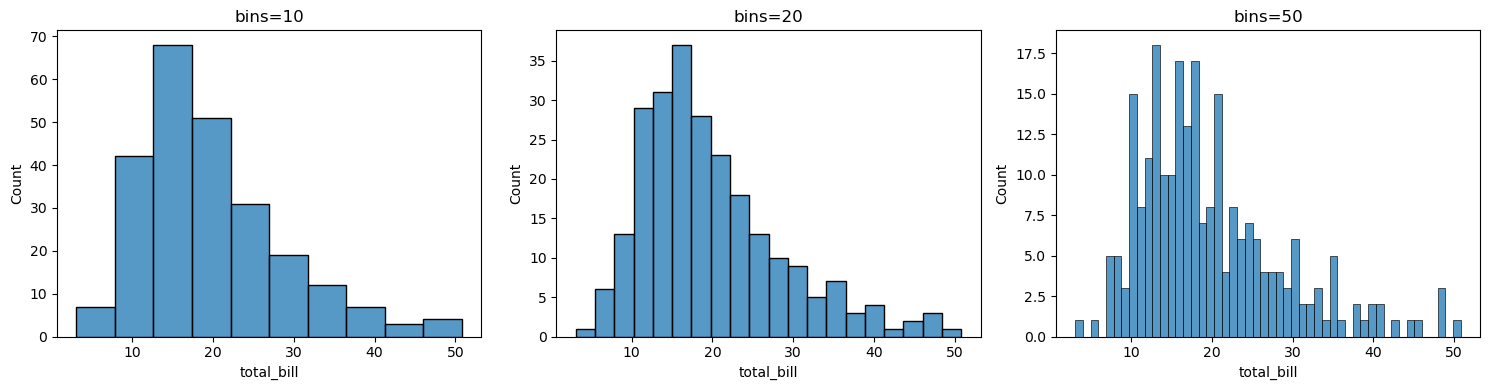

In [4]:
# c) Solution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, b in zip(axes, [10, 20, 50]):
    sns.histplot(tips["total_bill"], bins=b, ax=ax)
    ax.set_title(f"bins={b}")

plt.tight_layout()

# Fewer bins give a smoother, more general view of the distribution.
# More bins reveal finer detail but can appear noisy.

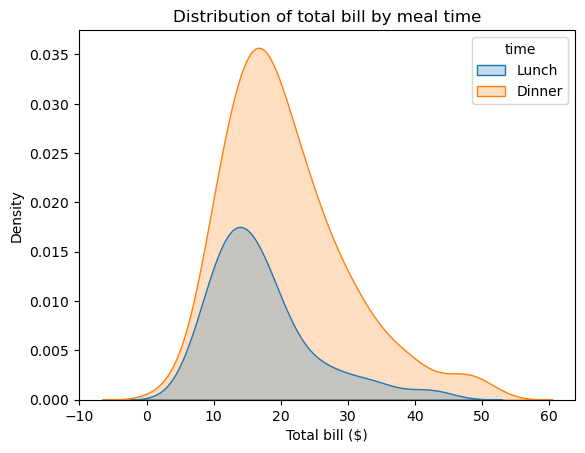

In [5]:
# d) Solution
sns.kdeplot(data=tips, x="total_bill", hue="time", fill=True)
plt.title("Distribution of total bill by meal time")
plt.xlabel("Total bill ($)");

# Dinner bills tend to be higher and more spread out than lunch bills.

### Exercise 2: Categorical plots and heatmaps

a) Create a box plot of `tip` grouped by `day` from the `tips` dataset. Which day has the widest spread in tip amounts? Are there outliers?

b) Create a bar plot showing the mean `total_bill` by `day`, with `hue="sex"`. Does the average bill differ between male and female customers across days?

c) Using `pd.pivot_table()`, create a pivot table showing the mean `tip` for each combination of `day` (rows) and `time` (columns). Display it as a heatmap with `sns.heatmap()` using `annot=True` and a color map of your choice. Are there any day/time combinations that stand out?

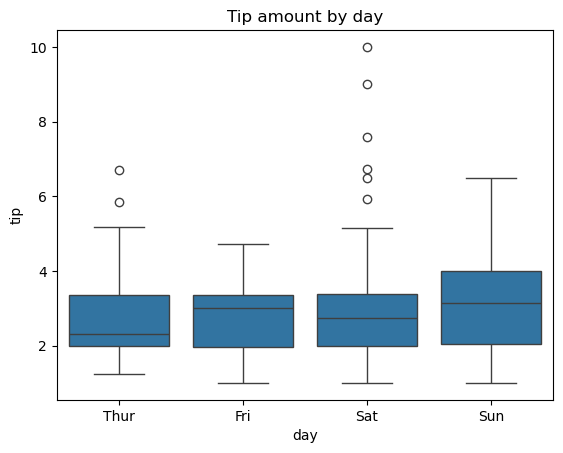

In [6]:
# a) Solution
sns.boxplot(data=tips, x="day", y="tip")
plt.title("Tip amount by day");

# Saturday has the widest spread. There are outliers on several days,
# visible as points beyond the whiskers.

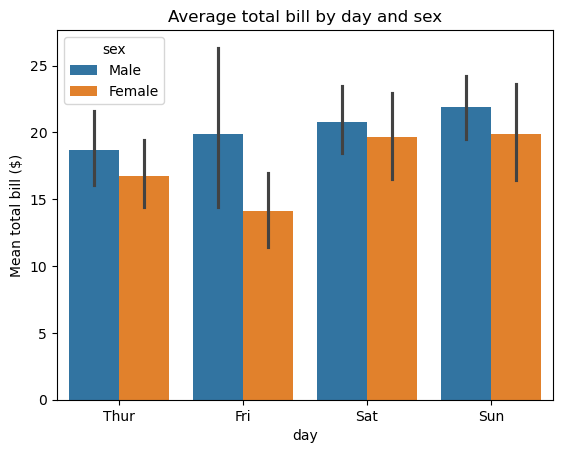

In [7]:
# b) Solution
sns.barplot(data=tips, x="day", y="total_bill", hue="sex")
plt.title("Average total bill by day and sex")
plt.ylabel("Mean total bill ($)");

# Male customers tend to have slightly higher average bills on most days.

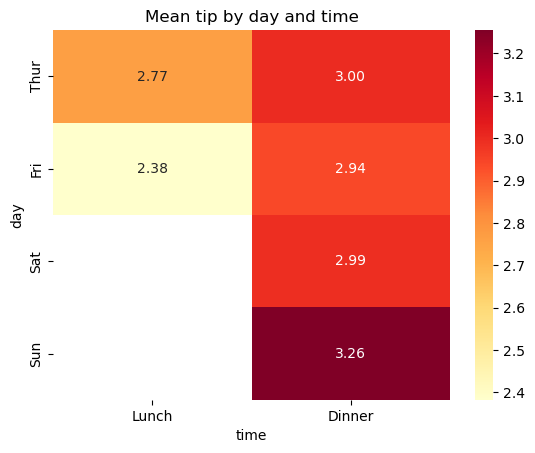

In [8]:
# c) Solution
pivot = pd.pivot_table(tips, values="tip", index="day", columns="time", aggfunc="mean", observed=False)

sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Mean tip by day and time");

# Sunday dinner stands out with the highest mean tip.
# Lunch data is only available for Thursday and Friday.

### Exercise 3: Customization and saving

a) Create a scatter plot of `total_bill` vs. `tip` from the `tips` dataset, colored by `smoker`. Set the figure size to 8 by 5 inches using `plt.figure(figsize=(8, 5))`. Add a descriptive title and axis labels.

b) Seaborn has five built-in themes: `darkgrid`, `whitegrid`, `dark`, `white`, and `ticks`. Test at least 3 of them by applying a new theme and running the code from one of the previous plotting tasks, such as 2a).

c) Save one of your plots to a file called `tips_scatter.png` into a folder `images` using `plt.savefig()` with `dpi=150` and `bbox_inches="tight"`. Verify that the file was created manually.

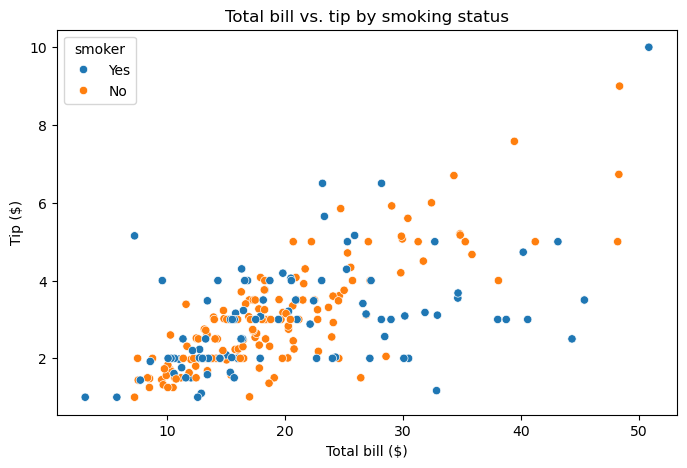

In [9]:
# a) Solution
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker")
plt.title("Total bill vs. tip by smoking status")
plt.xlabel("Total bill ($)")
plt.ylabel("Tip ($)");

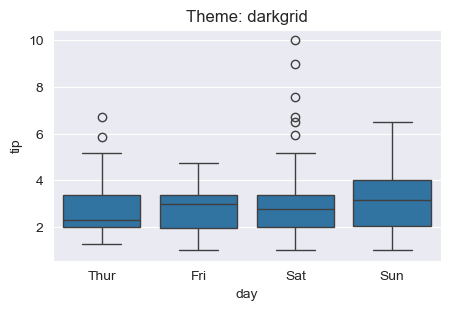

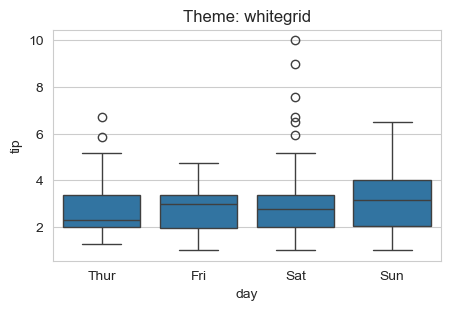

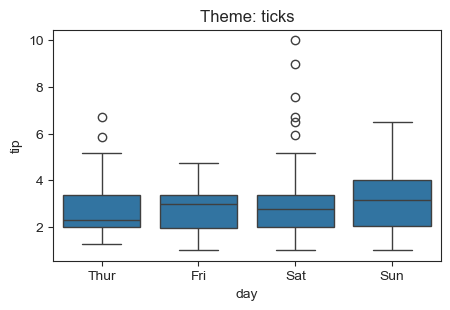

In [10]:
# b) Solution: testing different themes
for style in ["darkgrid", "whitegrid", "ticks"]:
    sns.set_style(style)
    plt.figure(figsize=(5, 3))
    sns.boxplot(data=tips, x="day", y="tip")
    plt.title(f"Theme: {style}")
    plt.show()

# Reset to default
sns.set_style("darkgrid")

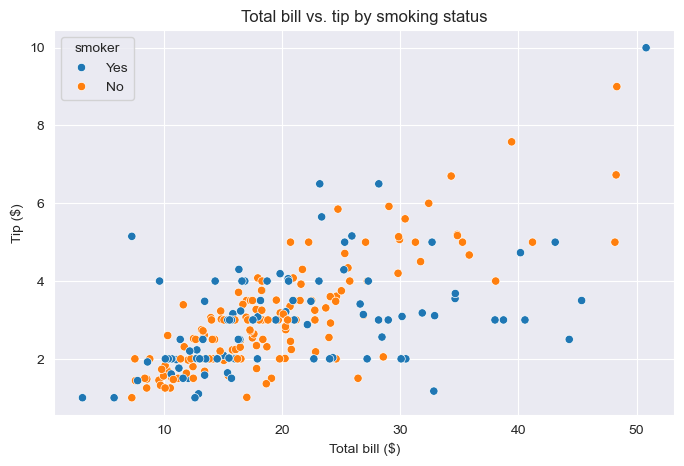

In [11]:
# c) Solution
import os
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker")
plt.title("Total bill vs. tip by smoking status")
plt.xlabel("Total bill ($)")
plt.ylabel("Tip ($)")
plt.savefig("images/tips_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 2: A/B testing

### Exercise 4: Loading and exploring the campaign data

The files `data/control_group.csv` and `data/test_group.csv` contain daily performance metrics from an A/B test comparing two online advertising campaigns during August 2019. Each file has 30 rows (one per day) with the following columns:

- `Campaign Name`: group identifier (Control Campaign or Test Campaign)
- `Date`: the date of the observation
- `Spend [USD]`: advertising spend in dollars
- `# of Impressions`: number of times the ad was shown
- `Reach`: number of unique users who saw the ad
- `# of Website Clicks`: number of clicks to the website
- `# of Searches`: number of product searches on the website
- `# of View Content`: number of product page views
- `# of Add to Cart`: number of add-to-cart events
- `# of Purchase`: number of completed purchases

The original dataset can be found [here](https://www.kaggle.com/datasets/amirmotefaker/ab-testing-dataset).

a) Load both CSV files. Note that the separator is `;`, not `,`. Print the shape and first 5 rows of each.

b) Combine the two DataFrames into a single DataFrame using `pd.concat()`. Verify that the result has 60 rows.

c) Check for missing values with `isna().sum()`. Which group has missing values? How many rows are affected?

d) Drop the rows with missing values and verify the new shape.

In [12]:
# a) Solution
control = pd.read_csv("data/control_group.csv", sep=";")
test = pd.read_csv("data/test_group.csv", sep=";")

print("Control shape:", control.shape)
display(control.head())
print()
print("Test shape:", test.shape)
display(test.head())

Control shape: (30, 10)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Test shape: (30, 10)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


In [13]:
# b) Solution
df = pd.concat([control, test], ignore_index=True)
print("Combined shape:", df.shape)

Combined shape: (60, 10)


In [14]:
# c) Solution
print(df.isna().sum())
print()
print("Missing values per campaign:")
print(df.isnull().groupby(df["Campaign Name"]).sum().sum(axis=1))

Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       1
Reach                  1
# of Website Clicks    1
# of Searches          1
# of View Content      1
# of Add to Cart       1
# of Purchase          1
dtype: int64

Missing values per campaign:
Campaign Name
Control Campaign    7
Test Campaign       0
dtype: int64


In [15]:
# d) Solution
df = df.dropna()
print("Shape after dropping missing values:", df.shape)

Shape after dropping missing values: (59, 10)


### Exercise 5: Exploratory data analysis

a) Compute the mean of each numeric column grouped by `Campaign Name`. Which campaign spent more on average? Which generated more purchases?

b) Run the code cells below and study the visualizations. Write your observations as comments or in a markdown cell after the plots.

In [16]:
# a) Solution
df.groupby("Campaign Name").mean(numeric_only=True)

,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
Campaign Name,,,,,,,,
Control Campaign,2304.068966,109559.758621,88844.931034,5320.793103,2221.310345,1943.793103,1300.000000,522.793103
Test Campaign,2563.066667,74584.800000,53491.566667,6032.333333,2418.966667,1858.000000,881.533333,521.233333


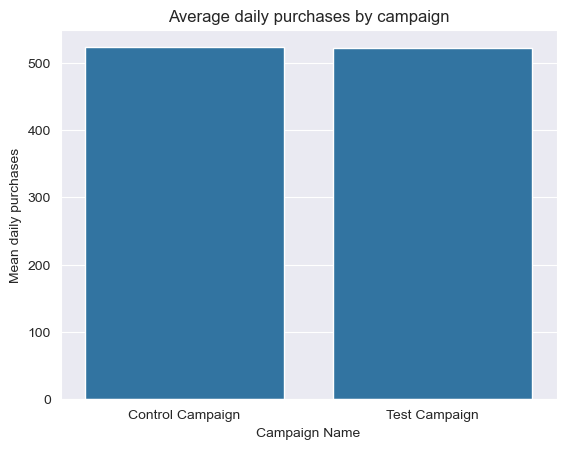

In [17]:
# Part b: bar plot comparing mean purchases
purchase_means = df.groupby("Campaign Name")["# of Purchase"].mean()

sns.barplot(x=purchase_means.index, y=purchase_means.values)
plt.ylabel("Mean daily purchases")
plt.title("Average daily purchases by campaign");

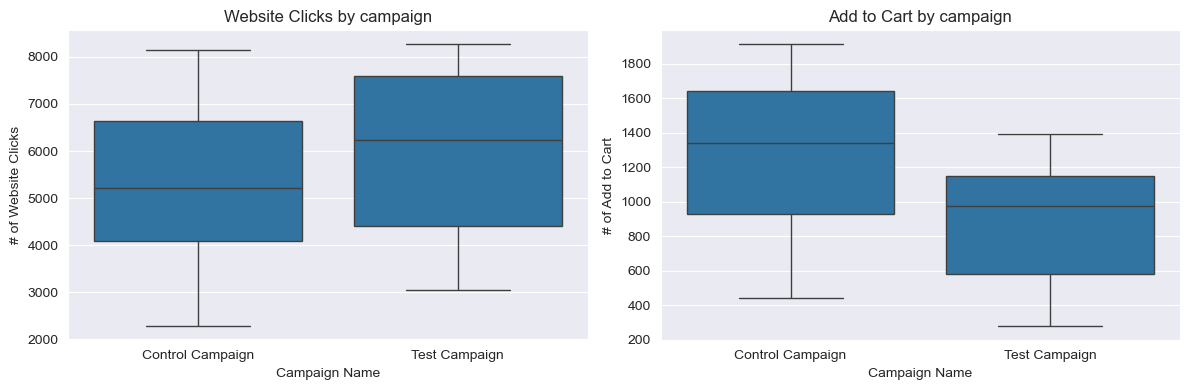

In [18]:
# Part c: side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="Campaign Name", y="# of Website Clicks", ax=axes[0])
axes[0].set_title("Website Clicks by campaign")

sns.boxplot(data=df, x="Campaign Name", y="# of Add to Cart", ax=axes[1])
axes[1].set_title("Add to Cart by campaign")

plt.tight_layout();

Campaign Name
Control Campaign    0.114772
Test Campaign       0.092312
Name: Conversion Rate, dtype: float64



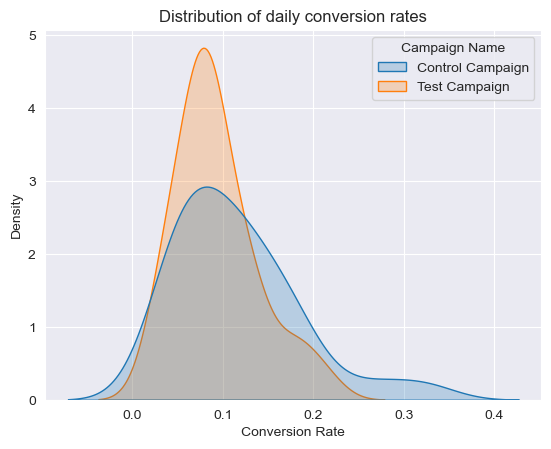

In [19]:
# Part d: conversion rate comparison
df["Conversion Rate"] = df["# of Purchase"] / df["# of Website Clicks"]

print(df.groupby("Campaign Name")["Conversion Rate"].mean())
print()

sns.kdeplot(data=df, x="Conversion Rate", hue="Campaign Name", fill=True)
plt.title("Distribution of daily conversion rates");

**Observations from the visualizations:**

- The bar plot shows that mean daily purchases are very similar between the two campaigns.
- The box plots reveal that the test campaign has higher and more variable website clicks, while in add-to-cart counts the test campaign is actually lower than the control.
- The conversion rate (purchases / website clicks) is higher for the control campaign, suggesting that although the test campaign drives more traffic, it converts visitors less efficiently.

### Exercise 6: Choosing and running statistical tests

In this dataset, each row represents daily aggregate metrics for a campaign. We are comparing two independent groups (Control vs. Test) on continuous daily measurements. The appropriate test for comparing the means of two independent groups on a continuous variable is the **independent two-sample t-test**.

Choose **either Option A (SciPy)** or **Option B (tea-tasting)** below.

---

#### Option A: SciPy

a) Import `scipy.stats`. Split the combined DataFrame into two separate DataFrames: one for Control and one for Test.

b) Run an independent two-sample t-test (`scipy.stats.ttest_ind()`) comparing the daily `# of Purchase` between the two campaigns. Print the t-statistic and p-value. Using a significance level of 0.05, is the difference statistically significant?

c) Run the same t-test for `# of Add to Cart` and `# of Website Clicks`. Which of these metrics show a statistically significant difference?

---

#### Option B: tea-tasting

[tea-tasting](https://tea-tasting.e10v.me/) is a Python package designed specifically for A/B test analysis. It provides a high-level API that handles common tasks such as running the appropriate statistical tests and computing confidence intervals.

a) Install tea-tasting with `!pip install tea-tasting` and import it. Since tea-tasting expects data where each row is one unit with a `variant` column, we can use our combined DataFrame with `Campaign Name` as the variant.

b) Define an experiment with `tt.Experiment()` that analyses the following metrics as `tt.Mean()`: `# of Purchase`, `# of Add to Cart`, and `# of Website Clicks`.

c) Run the experiment using `.analyze()` with `Campaign Name` as the variant column. Print the results. Which metrics show a statistically significant difference?

In [21]:
# Option A: SciPy
from scipy import stats

# a) Split into two groups
control_data = df[df["Campaign Name"] == "Control Campaign"]
test_data = df[df["Campaign Name"] == "Test Campaign"]

print(f"Control rows: {len(control_data)}, Test rows: {len(test_data)}")

Control rows: 29, Test rows: 30


In [22]:
# b) t-test for # of Purchase
t_stat, p_val = stats.ttest_ind(control_data["# of Purchase"], test_data["# of Purchase"])
print(f"Purchases: t = {t_stat:.4f}, p = {p_val:.4f}")
print(f"Significant at 0.05? {'Yes' if p_val < 0.05 else 'No'}")

Purchases: t = 0.0301, p = 0.9761
Significant at 0.05? No


In [23]:
# c) t-tests for Add to Cart and Spend

# Add to Cart
t_stat, p_val = stats.ttest_ind(control_data["# of Add to Cart"], test_data["# of Add to Cart"])
print(f"# of Add to Cart: t = {t_stat:.4f}, p = {p_val:.4f}")
print(f"Significant at 0.05? {'Yes' if p_val < 0.05 else 'No'}")

print()

# Spend [USD]
t_stat, p_val = stats.ttest_ind(control_data["# of Website Clicks"], test_data["# of Website Clicks"])
print(f"# of Website Clicks [USD]: t = {t_stat:.4f}, p = {p_val:.4f}")
print(f"Significant at 0.05? {'Yes' if p_val < 0.05 else 'No'}")

# of Add to Cart: t = 4.2491, p = 0.0001
Significant at 0.05? Yes

# of Website Clicks [USD]: t = -1.5769, p = 0.1204
Significant at 0.05? No


In [24]:
# Option B: tea-tasting
# !pip install tea-tasting
import tea_tasting as tt

# b) Define the experiment
experiment = tt.Experiment(
    purchases=tt.Mean("# of Purchase"),
    add_to_cart=tt.Mean("# of Add to Cart"),
    clicks=tt.Mean("# of Website Clicks"),
    variant = "Campaign Name"
)

# c) Run the analysis
results = experiment.analyze(df, control="Control Campaign")
print(results)

metric      control treatment rel_effect_size rel_effect_size_ci   pvalue
purchases       523       521          -0.30%        [-18%, 22%]    0.976
add_to_cart    1300       882            -32%       [-44%, -18%] 8.69e-05
clicks         5321      6032             13%       [-3.5%, 33%]    0.121


### Exercise 7: Interpreting the results

This exercise has no code. Answer the following in a markdown cell or as comments:

Summarize your findings: for which metrics was the difference between the two campaigns statistically significant?

Two metrics show a statistically significant difference between the campaigns:

- `# of Add to Cart`: the control campaign had significantly more add-to-cart events per day (mean 1300 vs. 882, p < 0.001).

Two metrics do not show a statistically significant difference:

- `# of Purchase`: means are nearly identical (523 vs. 521, p = 0.976).
- `# of Website Clicks`: the test campaign had a numerically higher mean (6032 vs. 5321) but the difference is not statistically significant (p = 0.121).

## Part 3: Text analysis with an LLM

### Exercise 8: Sentiment analysis

In this exercise you will use a large language model to classify the sentiment of customer reviews. You can use **either** a local model via Ollama **or** a cloud API via Gemini. Choose the option that works best for your setup.

**Option A: Ollama (local model)**

```python
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)
MODEL = "llama3.2"

def ask_llm(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content
```

**Option B: Gemini (cloud API)**

```python
from dotenv import load_dotenv
import os
from google import genai

load_dotenv()
api_key = os.environ.get("GEMINI_API_KEY")
gemini_client = genai.Client(api_key=api_key)
GEMINI_MODEL = "gemini-2.5-flash-lite"

def ask_llm(prompt):
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=prompt
    )
    return response.text
```

a) Choose one of the options above and set up the client. Test that it works by asking: `"What is sentiment analysis? Answer in one sentence."`

b) Create the following DataFrame of fictional reviews for a sushi restaurant:

```python
reviews = pd.DataFrame({
    "review_id": [1, 2, 3, 4, 5, 6],
    "review_text": [
        "Best sushi in town! The salmon nigiri was incredibly fresh and the miso soup was perfect.",
        "Waited 45 minutes for our food and when it arrived the rice was cold. Very disappointing experience.",
        "The fish was fresh but nothing special. Decent enough for a quick lunch, fair price for what you get.",
        "Dragon roll was absolutely amazing and the staff were so friendly. Will definitely come back!",
        "Found a hair in my ramen. The manager did not seem to care at all. Never coming back.",
        "Lovely atmosphere and good green tea. The sashimi platter was fine but the tempura was a bit greasy."
    ]
})
```

c) Write a function `analyse_sentiment(text)` that sends a prompt to the LLM asking it to classify the sentiment as Positive, Negative, or Neutral. The function should return the sentiment label as a string. **Hint:** instruct the model to respond with exactly one word.

d) Apply the function to all reviews using `.apply()` and store the results in a new column called `sentiment`. Print the resulting DataFrame. Do the labels match your own judgment?

In [26]:
# a) Solution: set up the client (Ollama example shown)
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)
MODEL = "llama3.2"

def ask_llm(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# Test
print(ask_llm("What is sentiment analysis? Answer in one sentence."))

Sentiment analysis, also known as opinion mining or emotion AI, is the process of automatically determining the emotional tone or attitude conveyed by language, such as positive, negative, or neutral, to extract insights and meaning from human-generated text or speech.


In [27]:
# b) Solution: create the reviews DataFrame
reviews = pd.DataFrame({
    "review_id": [1, 2, 3, 4, 5, 6],
    "review_text": [
        "Best sushi in town! The salmon nigiri was incredibly fresh and the miso soup was perfect.",
        "Waited 45 minutes for our food and when it arrived the rice was cold. Very disappointing experience.",
        "The fish was fresh but nothing special. Decent enough for a quick lunch, fair price for what you get.",
        "Dragon roll was absolutely amazing and the staff were so friendly. Will definitely come back!",
        "Found a hair in my ramen. The manager did not seem to care at all. Never coming back.",
        "Lovely atmosphere and good green tea. The sashimi platter was fine but the tempura was a bit greasy."
    ]
})

reviews

,review_id,review_text
0,1,Best sushi in town! The salmon nigiri was incr...
1,2,Waited 45 minutes for our food and when it arr...
2,3,The fish was fresh but nothing special. Decent...
3,4,Dragon roll was absolutely amazing and the sta...
4,5,Found a hair in my ramen. The manager did not ...
5,6,Lovely atmosphere and good green tea. The sash...


In [28]:
# c) Solution: sentiment analysis function
def analyse_sentiment(text):
    prompt = (
        f"Classify the sentiment of the following review as exactly one word: "
        f"Positive, Negative, or Neutral.\n\n"
        f"Review: {text}"
    )
    result = ask_llm(prompt).strip()
    return result

In [29]:
# d) Solution: apply to all reviews
reviews["sentiment"] = reviews["review_text"].apply(analyse_sentiment)
reviews

,review_id,review_text,sentiment
0,1,Best sushi in town! The salmon nigiri was incr...,Positive
1,2,Waited 45 minutes for our food and when it arr...,Negative
2,3,The fish was fresh but nothing special. Decent...,Neutral
3,4,Dragon roll was absolutely amazing and the sta...,Positive
4,5,Found a hair in my ramen. The manager did not ...,Negative
5,6,Lovely atmosphere and good green tea. The sash...,Neutral.
